In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv("SeoulBikeData.csv")

# 내가 해야될 부분 '강수량과 습도에 따른 대여량'

#전처리를 해야하는데

#컬럼확인
print(df.columns)

#RentedBike max치 구하기
print(df["Rented Bike Count"].max())
#RentedBike 평균
print(df["Rented Bike Count"].mean())

#이상치값 제거하기
# RBC = df["Rented Bike Count"]
# Q1 =RBC.quantile(0.25)
# Q3 = RBC.quantile(0.75)
# IQR = Q3 - Q1
# outliers = RBC[( RBC < Q1 - IQR*1.5) | (RBC > Q3 + IQR*1.5)]
#print(outliers)

df.loc[df["Rented Bike Count"] >= 20000, "Rented Bike Count"] = np.nan
df.loc[df["Rainfall"] < 0, "Rainfall"] = np.nan
df.loc[df["Snowfall"] < 0, "Snowfall"] = np.nan


#group by
df2 = df.groupby("Seasons")["Rainfall"].sum()
df3 = df.groupby("Seasons")["Snowfall"].sum()
#강수량
print(df2)
#강설량
print(df3)
# 계절별 강설량, 강수량 총합
df_sum = df2 + df3
print(df_sum)

#계절별 강수량, 강설량, 시간별 빌린 자전거개수
df4 = df.groupby("Seasons")[["Rainfall", "Humidity", "Rented Bike Count"]].mean()
print(df4)



#습도의 이상치 제거
df.loc[df["Humidity"] < 0, "Humidity"] = np.nan
df.loc[df["Humidity"] > 100, "Humidity"] = np.nan

print(df["Humidity"].describe())


Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
       'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day',
       'Temperature(째C)'],
      dtype='str')
20000
792.7384703196348
Seasons
Autumn    268.1
Spring    401.8
Summer    557.7
Winter     70.9
Name: Rainfall, dtype: float64
Seasons
Autumn    123.0
Spring      0.0
Summer      0.0
Winter    534.6
Name: Snowfall, dtype: float64
Seasons
Autumn    391.1
Spring    401.8
Summer    557.7
Winter    605.5
dtype: float64
         Rainfall   Humidity  Rented Bike Count
Seasons                                        
Autumn   0.122925  59.902473         819.782069
Spring   0.182636  59.239130         730.878981
Summer   0.253846  65.410326        1033.139736
Winter   0.032946  50.445833         225.620000
count    8740.000000
mean       58.239817
std        20.370870
min         0.000000
25%        42.000000
50%        57.000000
7

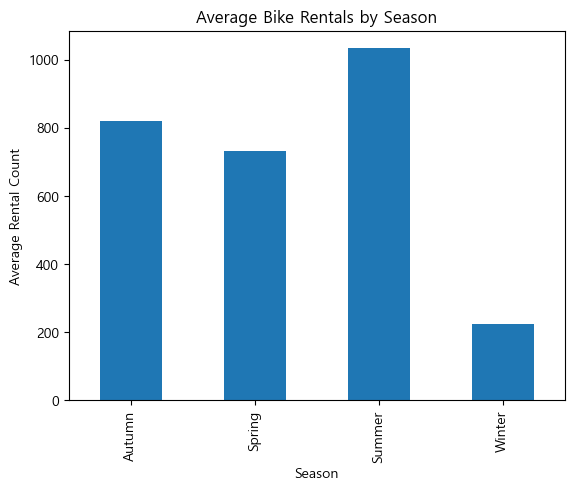

In [24]:
#막대그래프 계절별 자전거 렌트 평균 횟수
season_mean = df.groupby("Seasons")["Rented Bike Count"].mean()

season_mean.plot(kind="bar")

plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rental Count")

plt.show()

                   Rainfall  Rented Bike Count
Rainfall             1.0000            -0.1233
Rented Bike Count   -0.1233             1.0000 



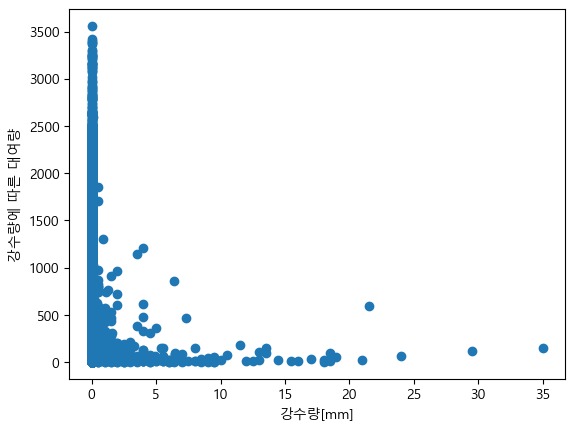

In [27]:
#강수량에 따른 대여량

plt.scatter(df["Rainfall"], df["Rented Bike Count"])
df2 = df[["Rainfall", "Rented Bike Count"]]
print(df2.corr(), '\n')
plt.xlabel("강수량[mm]")
plt.ylabel("강수량에 따른 대여량")
plt.show()

                   Humidity  Rented Bike Count
Humidity           1.000000          -0.201364
Rented Bike Count -0.201364           1.000000 



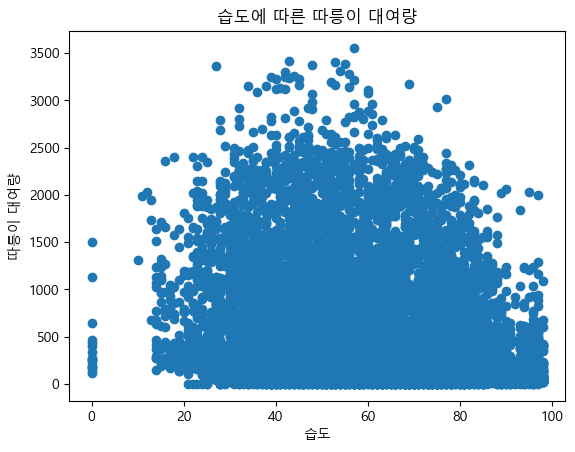

In [26]:
#습도에 따른 대여량
plt.scatter(df["Humidity"],
            df["Rented Bike Count"])
df2 = df[["Humidity", "Rented Bike Count"]]

print(df2.corr(), '\n')

plt.xlabel("습도")
plt.ylabel("따릉이 대여량")
plt.title("습도에 따른 따릉이 대여량")

plt.show()